### [Step 1] 대분류 장르별 핵심 하위 태그(Co-occurring Tags) 분석
스팀 인디 게임의 6대 주요 장르(Action, RPG 등)를 기준으로, 각 장르 내에서 어떤 세부 소재나 시스템 태그들이 가장 빈번하게 결합되는지 동시 출현 빈도를 분석합니다. 이를 통해 각 장르의 표준적인 구성 요소를 파악합니다.

데이터를 불러오고 전처리하는 중...

▶ 대분류 장르별 핵심 하위 태그(Co-occurring Tags) 분석


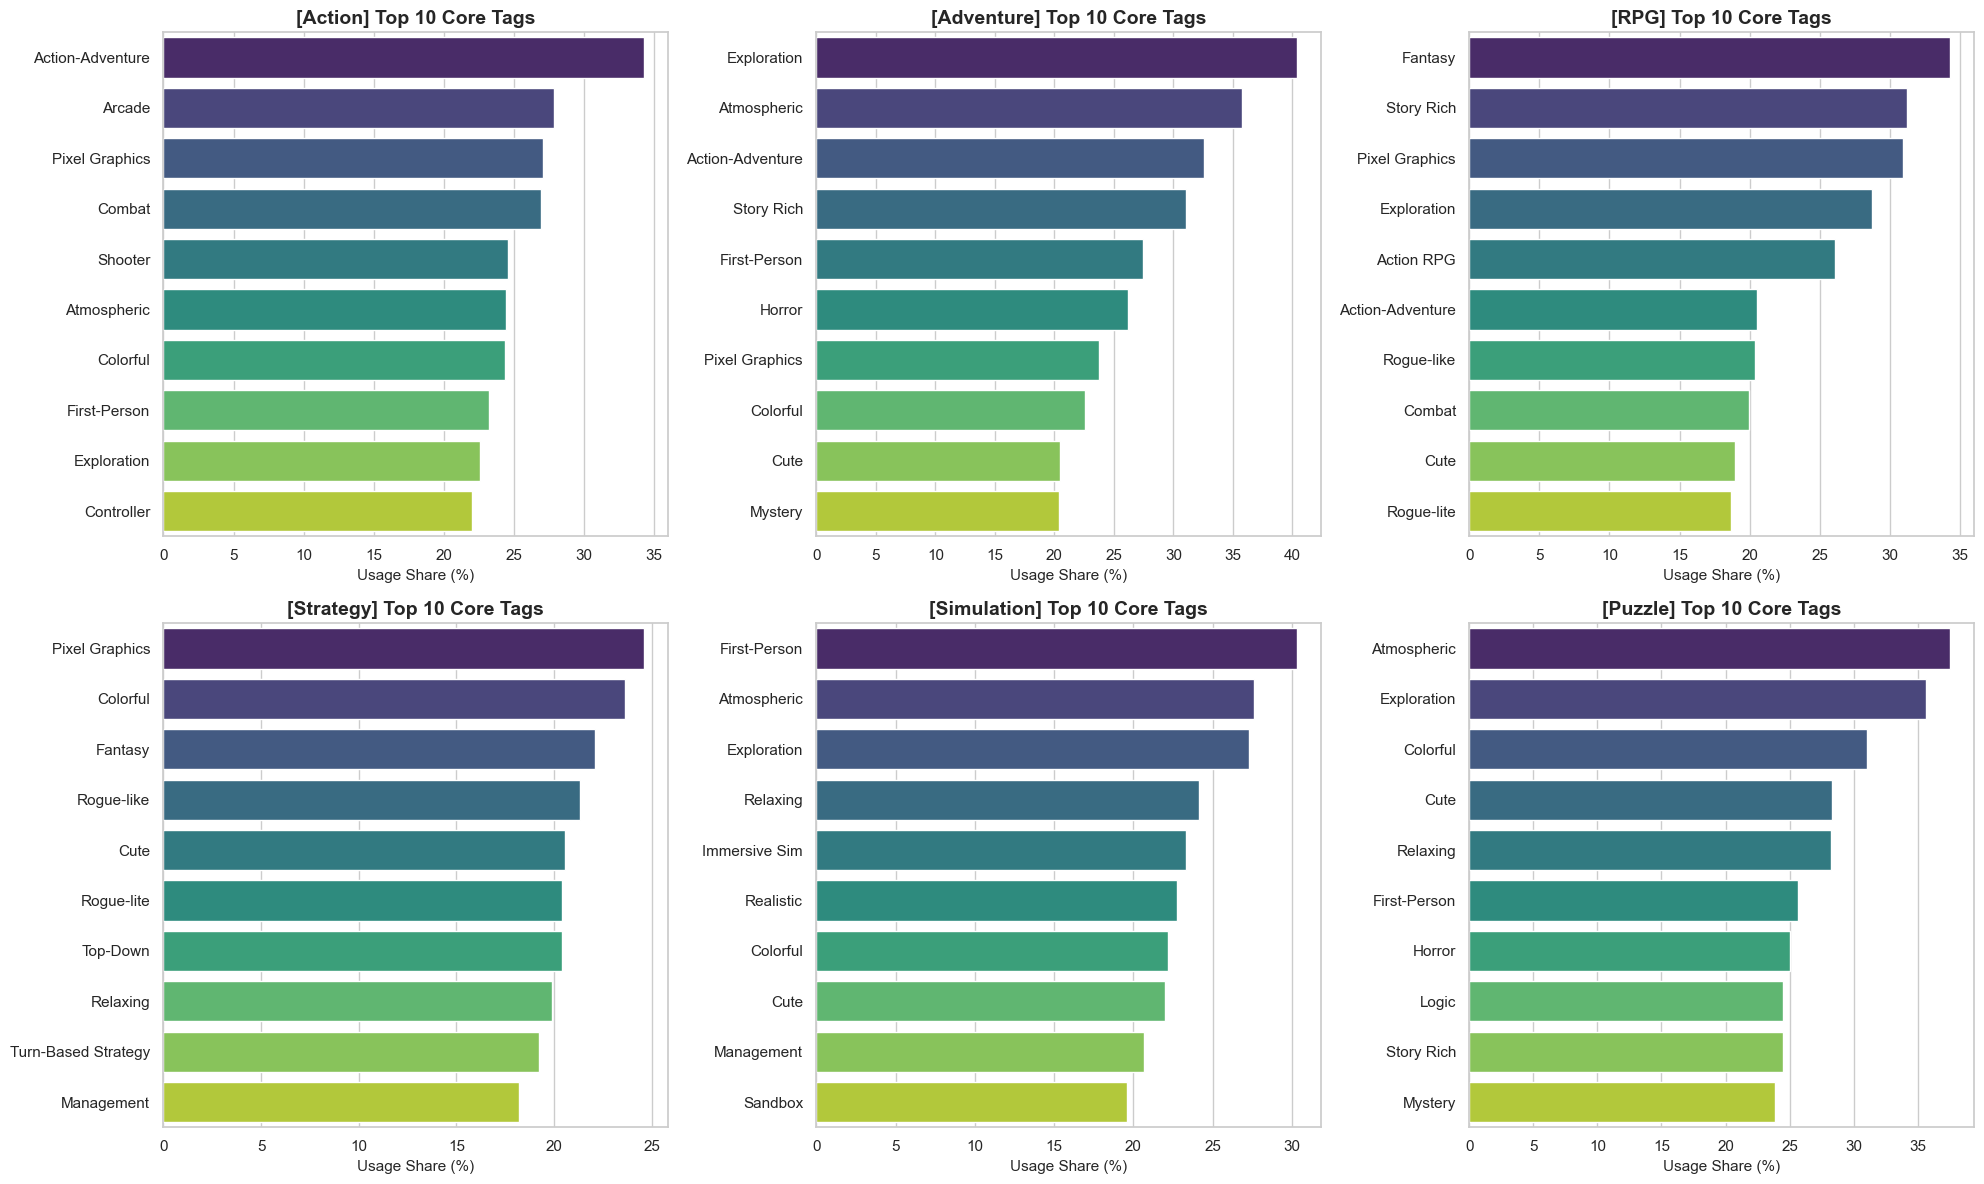


💡 [데이터 표] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Exploration,Fantasy,Pixel Graphics,First-Person,Atmospheric
Top 2,Arcade,Atmospheric,Story Rich,Colorful,Atmospheric,Exploration
Top 3,Pixel Graphics,Action-Adventure,Pixel Graphics,Fantasy,Exploration,Colorful
Top 4,Combat,Story Rich,Exploration,Rogue-like,Relaxing,Cute
Top 5,Shooter,First-Person,Action RPG,Cute,Immersive Sim,Relaxing
Top 6,Atmospheric,Horror,Action-Adventure,Rogue-lite,Realistic,First-Person
Top 7,Colorful,Pixel Graphics,Rogue-like,Top-Down,Colorful,Horror
Top 8,First-Person,Colorful,Combat,Relaxing,Cute,Logic
Top 9,Exploration,Cute,Cute,Turn-Based Strategy,Management,Story Rich
Top 10,Controller,Mystery,Rogue-lite,Management,Sandbox,Mystery


In [1]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# 1. 시각화 기본 설정
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# ==========================================
# [1단계] 데이터 로드 및 전처리
# ==========================================
print("데이터를 불러오고 전처리하는 중...\n")

# 파일 경로 (기존 경로 사용)
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

# 태그 문자열(dict 형태)을 리스트로 파싱
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_all['tag_list'] = df_all['tags'].apply(extract_tags)

# ==========================================
# [2단계] 대분류 장르별 인기 태그(Co-occurrence) 분석
# ==========================================
print("="*60)
print("▶ 대분류 장르별 핵심 하위 태그(Co-occurring Tags) 분석")
print("="*60)

# 분석할 대분류 6대 핵심 장르 설정 (변경 가능)
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']

# 분석에서 제외할 범용/공통 태그 (특징을 명확히 뽑기 위함)
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}

# 2x3 시각화 그리드 설정
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, genre in enumerate(target_genres):
    # 1. 해당 장르 태그를 보유한 게임만 필터링
    genre_df = df_all[df_all['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    # 2. 해당 장르 게임들이 가진 '다른' 모든 태그 수집
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    # 3. 가장 많이 함께 쓰인 태그 추출 및 비율 계산
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    
    genre_top_tags[genre] = top10_tags
    
    # 4. 시각화 (가로 막대 그래프)
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], hue='Tag', palette='viridis', legend=False)
    axes[i].set_title(f"[{genre}] Top 10 Core Tags", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Usage Share (%)", fontsize=11)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# ==========================================
# [3단계] 결과 표(DataFrame) 출력
# ==========================================
print("\n💡 [데이터 표] 장르별 핵심 동반 태그 TOP 10 요약")
# 길이가 다를 수 있으므로 정렬 후 데이터프레임화
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

### [Step 2] 최상위 흥행 티어(HH, MH, HM)의 장르별 성공 필수 태그 분석
전체 데이터가 아닌, 상업적 성과와 작품성이 검증된 최상위 3개 티어 게임들만 추출하여 장르별 핵심 태그를 분석합니다. 성공한 게임들 사이에서 공통적으로 발견되는 '미슐랭 3스타 레시피'와 같은 필수 요소를 도출합니다.

HH, MH, HM 최상위 티어 데이터를 정제하는 중...

✅ 성공! 총 3255개의 최상위(HH, MH, HM) 게임 데이터를 확보했습니다!

▶ [최상위 티어 전용] 대분류 장르별 핵심 하위 태그 분석


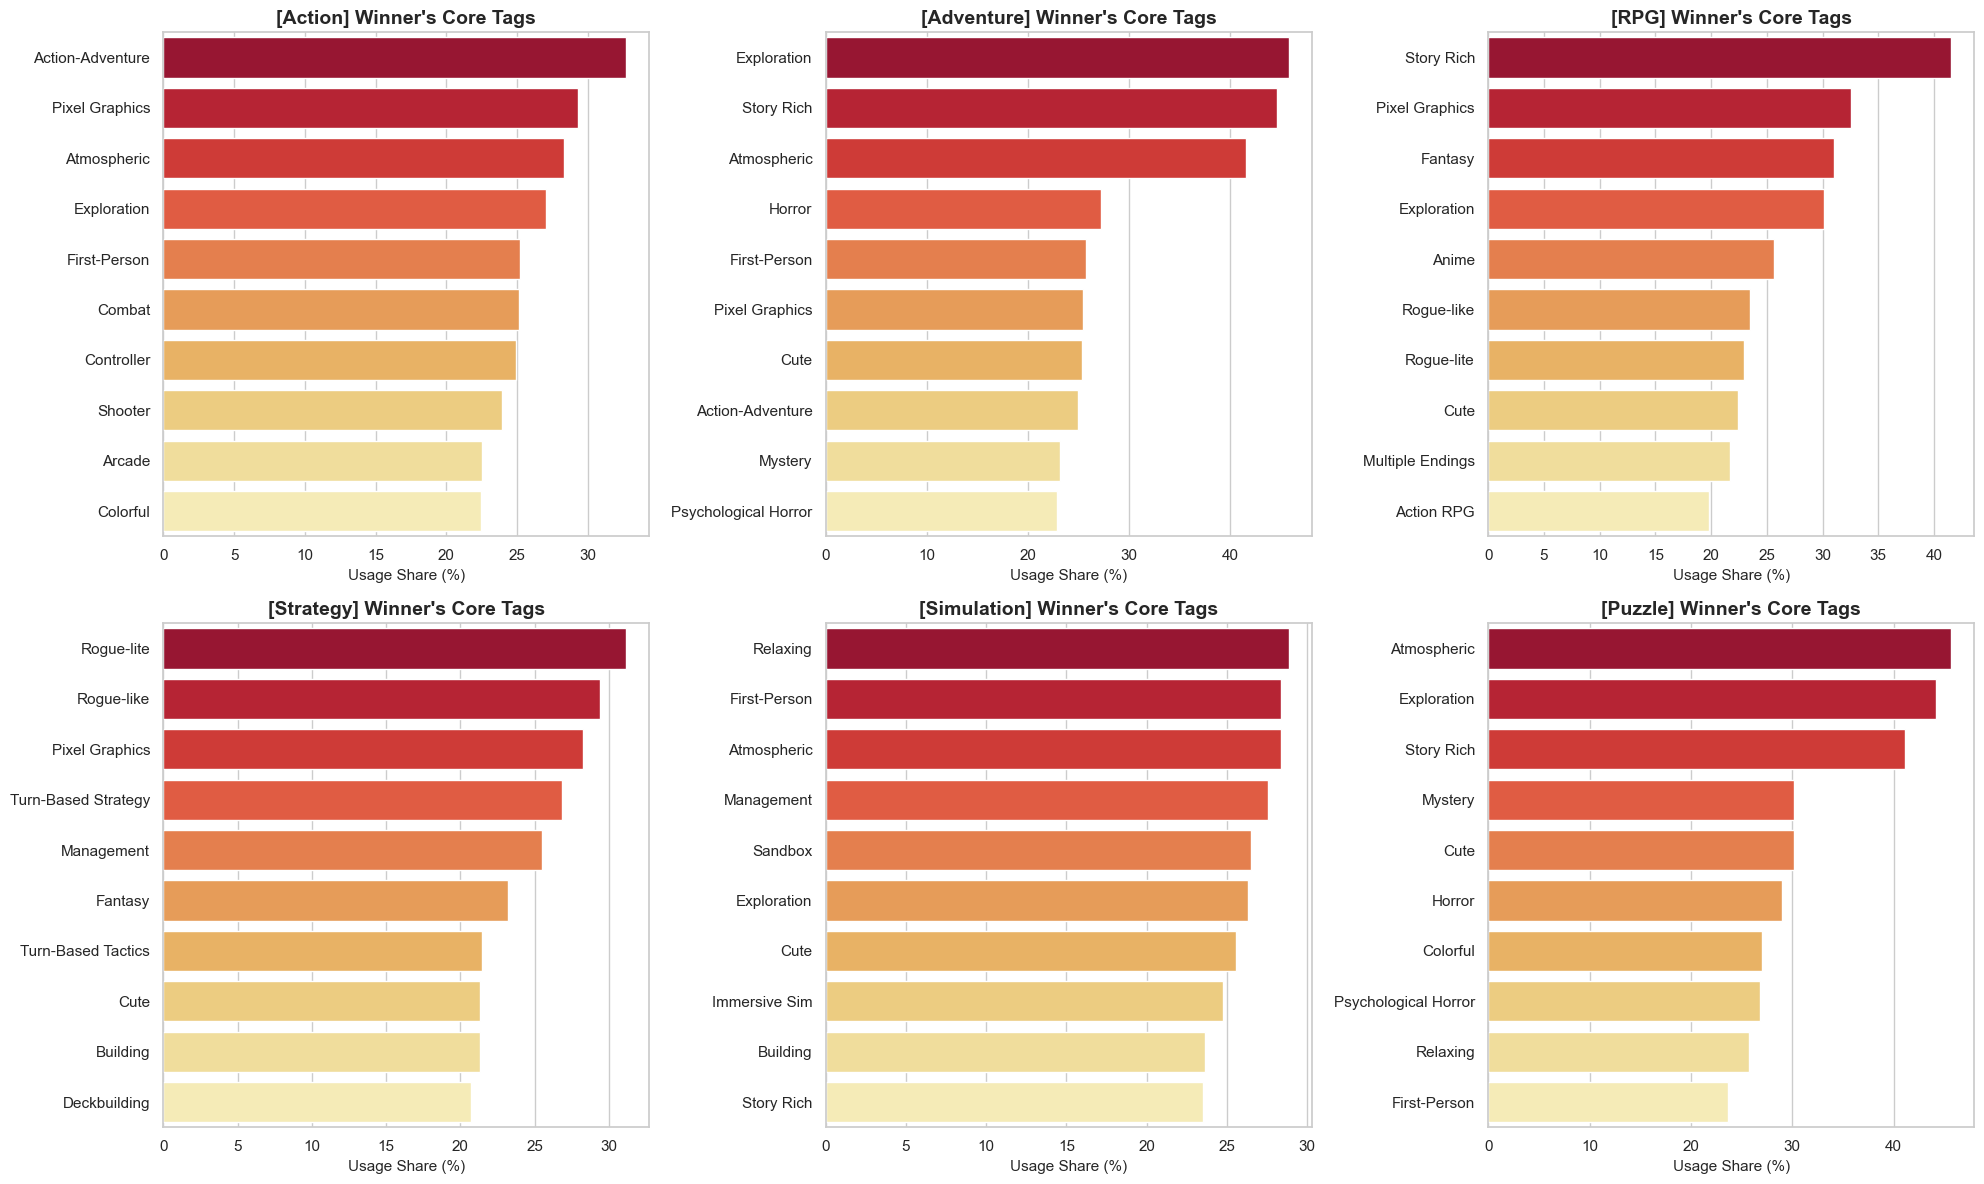


💡 [최상위 티어 미슐랭 레시피] 장르별 성공 필수 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Rank 1,Action-Adventure,Exploration,Story Rich,Rogue-lite,Relaxing,Atmospheric
Rank 2,Pixel Graphics,Story Rich,Pixel Graphics,Rogue-like,First-Person,Exploration
Rank 3,Atmospheric,Atmospheric,Fantasy,Pixel Graphics,Atmospheric,Story Rich
Rank 4,Exploration,Horror,Exploration,Turn-Based Strategy,Management,Mystery
Rank 5,First-Person,First-Person,Anime,Management,Sandbox,Cute
Rank 6,Combat,Pixel Graphics,Rogue-like,Fantasy,Exploration,Horror
Rank 7,Controller,Cute,Rogue-lite,Turn-Based Tactics,Cute,Colorful
Rank 8,Shooter,Action-Adventure,Cute,Cute,Immersive Sim,Psychological Horror
Rank 9,Arcade,Mystery,Multiple Endings,Building,Building,Relaxing
Rank 10,Colorful,Psychological Horror,Action RPG,Deckbuilding,Story Rich,First-Person


In [3]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# 1. 시각화 기본 설정
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# ==========================================
# [1단계] 최상위 티어 데이터 로드 및 필터링
# ==========================================
print("HH, MH, HM 최상위 티어 데이터를 정제하는 중...\n")

# 파일 경로
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'
df_graded = pd.read_csv(path_graded)
df_graded.columns = df_graded.columns.str.strip()

# 🎯 파일 스캔 결과 반영: 'performance_grade' 컬럼 및 정확한 데이터값 사용
GRADE_COLUMN = 'performance_grade' 
target_grades = ['high_high', 'mid_high', 'high_mid'] 

# 필터링 진행
df_top_tier = df_graded[df_graded[GRADE_COLUMN].isin(target_grades)].copy()

print(f"✅ 성공! 총 {len(df_top_tier)}개의 최상위(HH, MH, HM) 게임 데이터를 확보했습니다!\n")

def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_top_tier['tag_list'] = df_top_tier['tags'].apply(extract_tags)

# ==========================================
# [2단계] 최상위 티어의 장르별 핵심 동반 태그 분석
# ==========================================
print("="*60)
print("▶ [최상위 티어 전용] 대분류 장르별 핵심 하위 태그 분석")
print("="*60)

target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}

# 2x3 시각화 그리드
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, genre in enumerate(target_genres):
    genre_df = df_top_tier[df_top_tier['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], hue='Tag', palette='YlOrRd_r', legend=False)
    axes[i].set_title(f"[{genre}] Winner's Core Tags", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Usage Share (%)", fontsize=11)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# ==========================================
# [3단계] 데이터 표 출력
# ==========================================
print("\n💡 [최상위 티어 미슐랭 레시피] 장르별 성공 필수 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Rank {i+1}" for i in range(10)]
display(summary_df)

### [Step 3] 티어별(HH vs HM vs MH) 독자적 DNA 비교 분석
대박 갓겜(HH), 상업적 히트작(HM), 매니아 명작(MH) 그룹 간의 태그 구성을 비교합니다. 각 그룹이 시장에서 어떻게 다른 포지셔닝을 취하고 있는지, 그리고 '판매량'과 '긍정률'을 모두 잡기 위해 필요한 태그 DNA가 무엇인지 분석합니다.

HH, HM, MH 데이터를 올바른 기준으로 다시 해부하는 중...



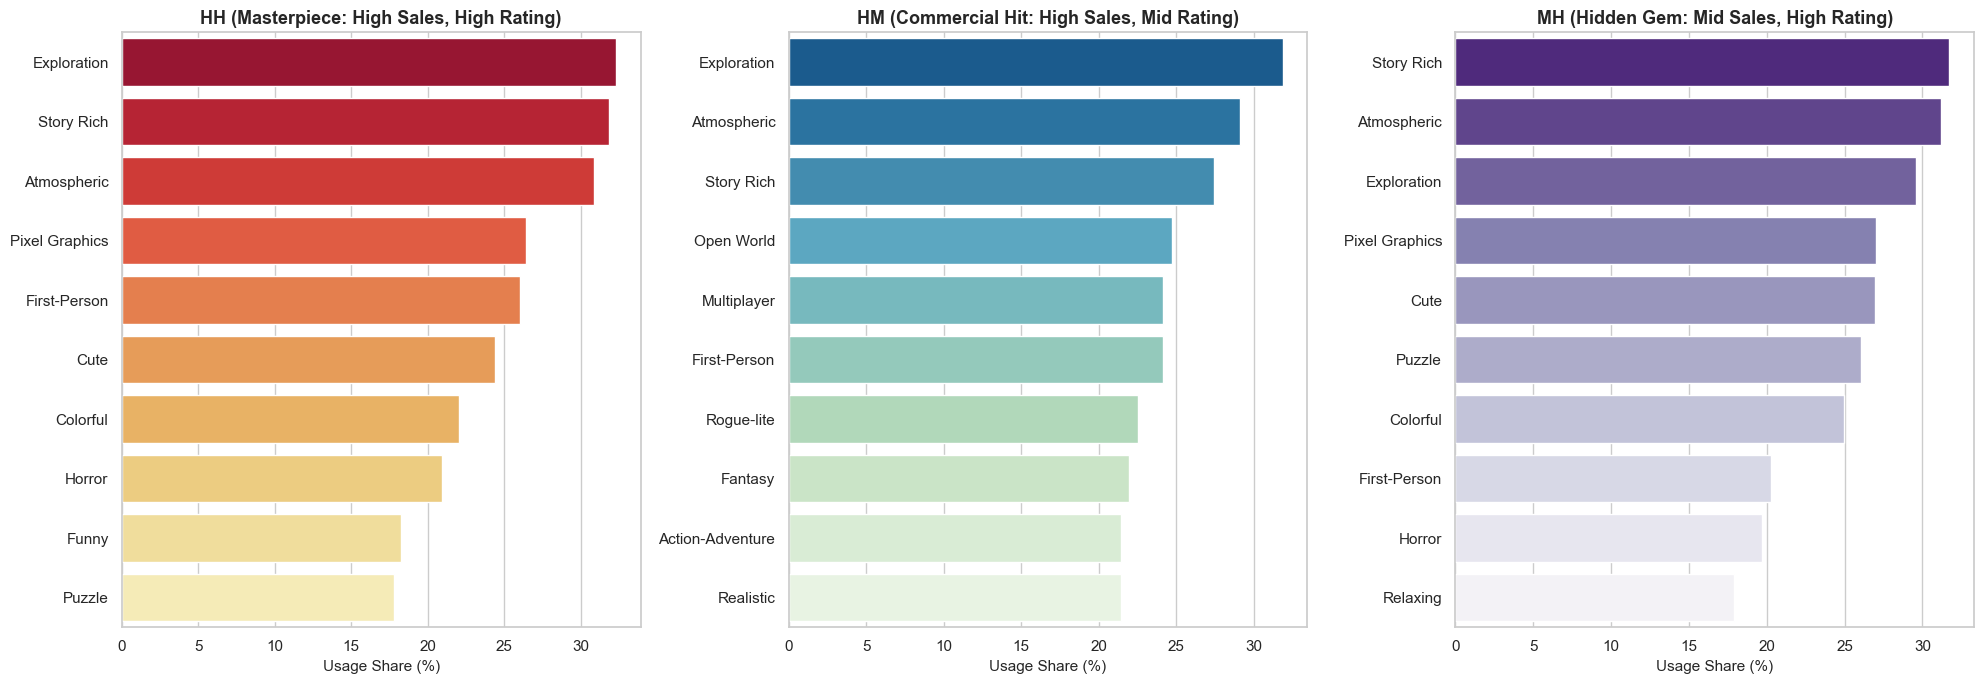


💡 [티어별 DNA 비교표] 각 그룹을 지배하는 TOP 10 태그


,HH,HM,MH
Rank 1,Exploration,Exploration,Story Rich
Rank 2,Story Rich,Atmospheric,Atmospheric
Rank 3,Atmospheric,Story Rich,Exploration
Rank 4,Pixel Graphics,Open World,Pixel Graphics
Rank 5,First-Person,Multiplayer,Cute
Rank 6,Cute,First-Person,Puzzle
Rank 7,Colorful,Rogue-lite,Colorful
Rank 8,Horror,Fantasy,First-Person
Rank 9,Funny,Action-Adventure,Horror
Rank 10,Puzzle,Realistic,Relaxing


In [4]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# 1. 시각화 기본 설정
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("HH, HM, MH 데이터를 올바른 기준으로 다시 해부하는 중...\n")

path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'
df_graded = pd.read_csv(path_graded)
df_graded.columns = df_graded.columns.str.strip()

GRADE_COLUMN = 'performance_grade' 

# 🎯 [수정됨] HM과 MH의 의미를 정확히 매핑
target_grades = {
    'high_high': 'HH (Masterpiece: High Sales, High Rating)',
    'high_mid': 'HM (Commercial Hit: High Sales, Mid Rating)', # 많이 팔렸으나 평가는 호불호
    'mid_high': 'MH (Hidden Gem: Mid Sales, High Rating)'      # 덜 팔렸으나 평가는 극찬
}

df_tiers = df_graded[df_graded[GRADE_COLUMN].isin(target_grades.keys())].copy()

def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_tiers['tag_list'] = df_tiers['tags'].apply(extract_tags)

common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access', 'Action', 'Adventure', 'RPG', 'Strategy', 'Simulation']

tier_top_tags = {}

# 1x3 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes = axes.flatten()

# HH: 황금(갓겜), HM: 청록(상업적), MH: 보라(매니아)
palettes = ['YlOrRd_r', 'GnBu_r', 'Purples_r']

for i, (grade, title) in enumerate(target_grades.items()):
    group_df = df_tiers[df_tiers[GRADE_COLUMN] == grade]
    total_games = len(group_df)
    
    all_tags = []
    for tags in group_df['tag_list']:
        filtered = [t for t in tags if t not in common_tags]
        all_tags.extend(filtered)
        
    tag_counts = Counter(all_tags)
    top10 = pd.Series({tag: (count / total_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    
    tier_top_tags[title[:2]] = top10 
    
    plot_df = top10.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], hue='Tag', palette=palettes[i], legend=False)
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Usage Share (%)", fontsize=11)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

print("\n💡 [티어별 DNA 비교표] 각 그룹을 지배하는 TOP 10 태그")
summary_df = pd.DataFrame({tier: tags.index.tolist() for tier, tags in tier_top_tags.items()})
summary_df.index = [f"Rank {i+1}" for i in range(10)]
display(summary_df)

### [Step 4] 장르별 & 티어별 복합 DNA 심층 분석 (TOP 10 레시피)
가장 정밀한 분석 단계로, 6대 장르 각각을 다시 3개 흥행 티어로 세분화하여 총 18개 그룹의 태그 TOP 10을 추출합니다. 장르 내에서 성공(HH)으로 가는 정답 경로와, 개발력 과욕으로 인한 함정 경로(HM)를 구분 짓는 세부 시스템 및 특징을 최종 정의합니다.

In [7]:
import pandas as pd
import ast
from collections import Counter
from IPython.display import display

# ==========================================
# [1단계] 데이터 로드 및 티어 분리
# ==========================================
print("장르별로 HH, HM, MH 티어를 TOP 10까지 확장 분석하는 중...\n")

path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'
df_graded = pd.read_csv(path_graded)
df_graded.columns = df_graded.columns.str.strip()

GRADE_COLUMN = 'performance_grade' 
target_grades = {
    'high_high': 'HH (갓겜: 판매량 High, 긍정률 High)',
    'high_mid': 'HM (상업겜: 판매량 High, 긍정률 Mid)', 
    'mid_high': 'MH (명작/매니아: 판매량 Mid, 긍정률 High)' 
}

df_tiers = df_graded[df_graded[GRADE_COLUMN].isin(target_grades.keys())].copy()

def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_tiers['tag_list'] = df_tiers['tags'].apply(extract_tags)

# ==========================================
# [2단계] 장르별 티어 쪼개기 및 분석 (TOP 10)
# ==========================================
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

# 장르별 결과를 담을 딕셔너리
genre_results = {}

for genre in target_genres:
    genre_df = df_tiers[df_tiers['tag_list'].apply(lambda x: genre in x)]
    
    tier_dict = {}
    for grade, tier_name in target_grades.items():
        group_df = genre_df[genre_df[GRADE_COLUMN] == grade]
        total_games = len(group_df)
        
        if total_games == 0:
            tier_dict[tier_name.split()[0]] = [] # 'HH', 'HM', 'MH' 이름만 추출
            continue
            
        all_tags = []
        for tags in group_df['tag_list']:
            filtered = [t for t in tags if t not in common_tags]
            all_tags.extend(filtered)
            
        tag_counts = Counter(all_tags)
        # 🎯 여기서 10개까지 추출합니다.
        top10 = pd.Series({tag: (count / total_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
        tier_dict[tier_name.split()[0]] = top10.index.tolist()
        
    genre_results[genre] = tier_dict

# ==========================================
# [3단계] 장르별 결과 표 출력
# ==========================================
for genre, tiers in genre_results.items():
    print(f"\n================ [ {genre} 장르 DNA 분석 (TOP 10) ] ================")
    df_temp = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in tiers.items()]))
    df_temp.index = [f"Rank {i+1}" for i in range(10)]
    display(df_temp.fillna('-'))

장르별로 HH, HM, MH 티어를 TOP 10까지 확장 분석하는 중...


================ [ Action 장르 DNA 분석 (TOP 10) ] ================


,HH,HM,MH
Rank 1,First-Person,Action-Adventure,Action-Adventure
Rank 2,Action-Adventure,Multiplayer,Pixel Graphics
Rank 3,Atmospheric,Atmospheric,Controller
Rank 4,Exploration,Action RPG,Atmospheric
Rank 5,Shooter,First-Person,Exploration
Rank 6,Pixel Graphics,Combat,Arcade
Rank 7,Combat,Exploration,Combat
Rank 8,Horror,Story Rich,Colorful
Rank 9,Action Roguelike,Online Co-Op,Shooter
Rank 10,Rogue-lite,Rogue-lite,Platformer



================ [ Adventure 장르 DNA 분석 (TOP 10) ] ================


,HH,HM,MH
Rank 1,Exploration,Exploration,Story Rich
Rank 2,Story Rich,Atmospheric,Exploration
Rank 3,Atmospheric,Story Rich,Atmospheric
Rank 4,First-Person,Action-Adventure,Cute
Rank 5,Horror,Open World,Horror
Rank 6,Pixel Graphics,Fantasy,Pixel Graphics
Rank 7,Action-Adventure,Action RPG,Action-Adventure
Rank 8,Psychological Horror,Horror,Colorful
Rank 9,Cute,Third Person,First-Person
Rank 10,Mystery,First-Person,Mystery



================ [ RPG 장르 DNA 분석 (TOP 10) ] ================


...

,HH,HM,MH
Rank 1,Rogue-lite,Rogue-lite,Rogue-lite
Rank 2,Rogue-like,Management,Rogue-like
Rank 3,Turn-Based Strategy,Fantasy,Pixel Graphics
Rank 4,Management,Rogue-like,Turn-Based Strategy
Rank 5,Building,Resource Management,Top-Down
Rank 6,Pixel Graphics,Turn-Based Strategy,Cute
Rank 7,Turn-Based Tactics,Sandbox,Fantasy
Rank 8,Deckbuilding,Pixel Graphics,Management
Rank 9,Sandbox,Turn-Based Combat,Turn-Based Tactics
Rank 10,Cute,Base-Building,Colorful



================ [ Simulation 장르 DNA 분석 (TOP 10) ] ================


,HH,HM,MH
Rank 1,Sandbox,Management,Atmospheric
Rank 2,Relaxing,Sandbox,Relaxing
Rank 3,Building,Building,First-Person
Rank 4,Exploration,Resource Management,Cute
Rank 5,First-Person,Base-Building,Management
Rank 6,Management,Open World,Exploration
Rank 7,Immersive Sim,Exploration,Story Rich
Rank 8,Cute,Life Sim,Immersive Sim
Rank 9,Atmospheric,Realistic,Colorful
Rank 10,Life Sim,Immersive Sim,Pixel Graphics



================ [ Puzzle 장르 DNA 분석 (TOP 10) ] ================


,HH,HM,MH
Rank 1,Exploration,Atmospheric,Atmospheric
Rank 2,Story Rich,Mystery,Exploration
Rank 3,Atmospheric,Horror,Story Rich
Rank 4,Horror,Exploration,Cute
Rank 5,Mystery,Story Rich,Colorful
Rank 6,Psychological Horror,First-Person,Mystery
Rank 7,Cute,Psychological Horror,Relaxing
Rank 8,First-Person,Thriller,Horror
Rank 9,Point & Click,Walking Simulator,Psychological Horror
Rank 10,Colorful,Fantasy,Pixel Graphics
